In [4]:
%%html
<script>
  function code_toggle() {
    if (code_shown){
      $('div.input').hide('500');
      $('#toggleButton').val('Show Code')
    } else {
      $('div.input').show('500');
      $('#toggleButton').val('Hide Code')
    }
    code_shown = !code_shown
  }

  $( document ).ready(function(){
    code_shown=false;
    $('div.input').hide()
  });
</script>
<form action="javascript:code_toggle()"><input type="submit" id="toggleButton" value="Show Code"></form>

<!---
Latex Macros
-->
$$
\newcommand{\Xs}{\mathcal{X}}
\newcommand{\Ys}{\mathcal{Y}}
\newcommand{\y}{\mathbf{y}}
\newcommand{\weights}{\mathbf{w}}
\newcommand{\balpha}{\boldsymbol{\alpha}}
\newcommand{\bbeta}{\boldsymbol{\beta}}
\newcommand{\aligns}{\mathbf{a}}
\newcommand{\align}{a}
\newcommand{\source}{\mathbf{s}}
\newcommand{\target}{\mathbf{t}}
\newcommand{\ssource}{s}
\newcommand{\starget}{t}
\newcommand{\repr}{\mathbf{f}}
\newcommand{\repry}{\mathbf{g}}
\newcommand{\bar}{\,|\,}
\newcommand{\x}{\mathbf{x}}
\newcommand{\prob}{p}
\newcommand{\Pulp}{\text{Pulp}}
\newcommand{\Fiction}{\text{Fiction}}
\newcommand{\PulpFiction}{\text{Pulp Fiction}}
\newcommand{\pnb}{\prob^{\text{NB}}}
\newcommand{\vocab}{V}
\newcommand{\params}{\boldsymbol{\theta}}
\newcommand{\param}{\theta}
\DeclareMathOperator{\perplexity}{PP}
\DeclareMathOperator{\argmax}{argmax}
\DeclareMathOperator{\argmin}{argmin}
\newcommand{\train}{\mathcal{D}}
\newcommand{\counts}[2]{\#_{#1}(#2) }
\newcommand{\length}[1]{\text{length}(#1) }
\newcommand{\indi}{\mathbb{I}}
$$

In [5]:
%%capture
%load_ext autoreload
%autoreload 2
%matplotlib inline
# %cd .. 
import sys
sys.path.append("..")
import random
import statnlpbook.util as util
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 5.0)
import random 
from collections import defaultdict
random.seed(2)

In [6]:
%%HTML
<style>
td,th {
    font-size: x-large;
    text-align: left;
}
</style>

# Text Classification 

Automatically classify input text into a set of **atomic (discrete) classes**

## Motivation
* **Information retrieval**: classify documents into topics, such as "sport" or "business"
* **Sentiment analysis**: classify tweets into being "positive" or "negative"  
* **Spam filters**: distinguish between "ham" and "spam"

<!-- TODO: Load Web Corpus, 4 Universities, something were Maxent works -->

## Sentiment Analysis as Text Classification
Let us focus on a specific task: sentiment analysis

* load data for this task from the [Movie Review dataset](https://www.cs.cornell.edu/people/pabo/movie-review-data/)

In [7]:
from os import listdir
from os.path import isfile, join
def load_from_dir(directory,label):
    """
    Load documents from a directory, and give them all the same label `label`.
    Params:
        directory: the directory to load the documents from.
        label: the label to assign to each document.
    Returns:
        a list of (x,y) pairs where x is a tokenised document (list of words), and y is the label `label`.
    """
    result = []
    for file in listdir(directory):
        with open(directory + file, 'r') as f:
            text = f.read()
            tokens = [t.strip() for t in text.split()]
            result.append((tokens,label))
    return result
 
data_pos = load_from_dir('../data/rt-2k/txt_sentoken/pos/', 'pos') 
data_neg = load_from_dir('../data/rt-2k/txt_sentoken/neg/', 'neg')
    
data_all = data_pos + data_neg

Let us look at some example data ...

In [8]:
" ".join(data_pos[4][0][110:199])

"charmingly effective romantic drama , this film offers insight into various types of relationships , presents us with interesting characters and excellent performances from the cast , and scratches beneath the surface of love and its many complex subtleties . how do people fall in love ? why do people fall out of love ? how do people fall back into love , once they've been hurt and left to join the lonely hearts club ? all of these questions and more , are touched upon in this film"

In [9]:
" ".join(data_neg[5][0][:200])

"to watch `battlefield earth' is to wallow in misery . it is one of the most ludicrously conceived efforts in recent history . it has a clumsily told story , insipid dialogue , shallow characterizations , ugly scene transitions , no evidence of dramatic arc , headache-inducing sound effects , and a resolution that is completely implausible . worse , there's the promise of a sequel . why ? ! save your money . some films go quickly to video . this one , however , should go straight to the sci-fi channel's `mystery science theatre . ' in the year 3000 , man has become an endangered species . most of humanity ( called ? man-animals' ) was destroyed generations ago in a battle against a race of plundering aliens ( called psychlos ) . survivors have either taken up shelter in caves or were enslaved to mine earth's resources for the rest of their lives . the aliens are a menacing looking humanoid species that stand nine-feet tall , who resemble inbred klingons . dimwitted as they are tall , t

## Rule-based Approach

The task: given the review text, return its sentiment. Can we write a program to solve this?

In [10]:
def rule_based_classifier(text):
    text = text.lower()
    if "charming" in text or "i love" in text:
        return "positive"
    elif "misery" in text or ("bad" in text and "not bad" not in text):
        return "negative"
    else:
        return "neutral"

A common approach is to use a *sentiment lexicon*: collection of all positive words and negative words.

| Word      | Sentiment Score |
|-----------|-----------------|
| Amazing   | 0.8             |
| Good      | 0.5             |
| Average   | 0.0             |
| Bad       | -0.5            |
| Terrible  | -0.8            |


<center><img src="../img/quiz_time.png"></center>

What limitations does the rule-based approach to text classification have?

Discuss and enter your answer(s) here:

# [tinyurl.com/diku-nlp-q3](https://tinyurl.com/diku-nlp-q3)

([Responses](https://docs.google.com/forms/d/1bXldAjGhvyycpN4k8zEccxS0PezgIgZjTMICVgJaR_E/edit#responses))

## Text Classification: Formal Definition

* Input space $\Xs$ are strings or sequences of tokens
* output space $\Ys$ is a set of labels
    * Example for document classification: $\Ys=\{ \text{sports},\text{business}\}$ 
    * Example for sentiment prediction: $\Ys=\{ \text{positive},\text{negative}, \text{neutral}\}$ 
* model $s_{\params}(\x,y)$ 
    * scores $y$ highly if it fits text $\x$
    

* **Discriminative** model:
    * Learn how to *discriminate best output based on input*: $\prob(y|\x) \propto s_{\params}(\x,y)$

## Discriminative Text Classification

Use data to learn how to estimate probabilities algorithmically - machine learning approach.

Frame the task as an optimisation problem and maximise the probability of the training set give the classifier parameters $\params$.


maximise $\prob_\params(\text{correct label} \bar \text{text})$

### Negative Log-Likelihood (NLL) Loss

Maximise the likelihood of the correct labels (given the input), or equivalently,

**Minimise** the **negative log-likelihood** of the correct labels

$$
\mathcal{L}(\params) = -\sum_{(\x,y) \in \train} \log\left(\prob(y|\x)\right)
$$

### Log-Linear Models

Model the score as

$$
s_\theta(y_i, \x) = \frac{\exp(\weights_i f(\x, y_i))}{\sum_{j=1}^C \exp(\weights_j f(\x, y_j))}
$$

This is also often called **softmax**.

### Feature Function

For log-linear models we need **feature functions** $f_i(\x, y)$ mapping input to a real value.

For simplicity $f_i(\x, y)$ depends only on $\x$, e.g.,

$$
f_{\text{Pulp}}(\x) = \counts{\x}{\text{Pulp}}
$$
i.e., the number of times *Pulp* appears in the input $\x$.  

## Minimising the Negative Log-Likelihood
No closed form solution

Use **iterative methods** such as (Stochastic) Gradient Descent (SGD)

### How to Find the Minimum?

In practice one of the following:
* Implement both optimisation and gradient calculation
* Use off-the-shelf optimisation library (such as scipy) and implement the gradient calculation
* Use a library that calculates gradients automatically (such as PyTorch or Tensorflow)
* Use a library that implements specific models (such as [scikit-learn](http://scikit-learn.org/))


## Regularisation
Estimating a log-linear models can lead to *overfitting*

* For example, reviews of movies often contain the **name** of the movie
* False *killer feature*: only appears in one training instance
* Weight can be set in way that we get perfect accuracy on this instance

*Regularise* the model by **penalising** large weights:

* Add a regularisation penalty to the training objective
* For example, the L2 or L1 norm of the weight vector (ridge/lasso regularisation)


$$
||\params||_1 = \left(\sum_{i=1}^N |w_i|\right)
$$
$$
||\params||_2 = \sqrt{\sum_{i=1}^N w_i^2}
$$

The hyperparameter $\alpha$ controls strength of regularisation:

$$
\mathcal{L}^1_\alpha(\params) = \mathcal{L}(\params) + \alpha ||\params||_1
$$
$$
\mathcal{L}^2_\alpha(\params) = \mathcal{L}(\params) + \alpha ||\params||_2
$$

Both L1 and L2 have their strength and weaknesses. 
* L1 regularisation can lead to sparse vectors with mostly zero weights
* L2 (also called "weight decay" in PyTorch) is more common in modern NLP

## Logistic Regression Toolkits
A log-linear model trained by minimising the NLL corresponds to training a **logistic regression** model

(or equivalently, a one-layer neural network)

The [logistic regression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) model is implemented in [scikit-learn](http://scikit-learn.org/stable/index.html). Let's use it to implement a simple classifier:

## Setup

Divide dataset to **train**, **test** and **development** (validation) sets

In [15]:
random.seed(0)
shuffled = list(data_all)
random.shuffle(shuffled)
train, dev, test = shuffled[:1600], shuffled[1600:1800], shuffled[1800:]
split = {"train": train, "dev": dev, "test": test}
{name: {label: sum(1 for (x,y) in data if y == label) for label in ("pos", "neg")} for name, data in split.items()}

{'train': {'pos': 815, 'neg': 785},
 'dev': {'pos': 95, 'neg': 105},
 'test': {'pos': 90, 'neg': 110}}

Convert $\x \in \Xs$ to a (sparse) feature vector $\mathbf{f}(\x)$:

In [16]:
from collections import Counter

def feats(x):
    return Counter(x)

x = ['pulp','fiction','fiction']
print(f"x = {x}")
print(f"f(x) = {feats(x)}")

x = ['pulp', 'fiction', 'fiction']
f(x) = Counter({'fiction': 2, 'pulp': 1})


Apply to training and validation instances:

In [17]:
from sklearn.feature_extraction import DictVectorizer
vectorizer = DictVectorizer()

train_X = vectorizer.fit_transform([feats(x) for x,_ in train])
dev_X = vectorizer.transform([feats(x) for x,_ in dev])
print(f"x = {dev[0][0]}")

x = ['i', 'remember', 'making', 'a', 'pact', ',', 'right', 'after', '`patch', "adams'", ',', 'to', 'not', 'be', 'easily', 'be', 'suckered', 'by', 'movies', 'dripping', 'with', 'sentimentality', '.', 'but', 'darn', 'it', ',', '`music', 'of', 'the', "heart'", 'is', 'just', 'layered', 'with', 'feel-good', 'material', 'and', 'bright', 'characterizations', '.', "it's", 'hard', 'to', 'dislike', 'a', 'movie', 'that', 'uses', 'such', 'skill', 'with', "it's", 'manipulation', '.', 'in', 'addition', ',', "it's", 'also', 'a', 'terrific', 'family', 'film', '.', 'this', 'is', 'the', 'true', 'story', 'of', 'violin', 'teacher', 'roberta', 'guaspari', ',', 'who', 'fought', 'the', 'school', 'board', 'to', 'keep', 'the', 'musical', 'program', 'active', 'in', 'a', 'handful', 'of', 'inner', 'city', 'harlem', 'schools', '.', 'it', 'could', 'also', 'be', 'described', 'as', '`mrs', '.', "streep's", "opus'", '.', 'yes', ',', 'meryl', 'streep', 'brings', 'her', 'dramatic', 'clout', 'to', 'the', 'demanding', 'ro

In [18]:
print(f"f(x) = {list(map(int, dev_X[0].toarray()[0]))}")

f(x) = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

scikit-learn prefers numbers as classes:

* $\text{positive}\rightarrow 0$
* $\text{negative}\rightarrow 1$

In [19]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

train_Y = label_encoder.fit_transform([y for _,y in train])
dev_Y = label_encoder.transform([y for _,y in dev])

print(f"first 10 labels in dev: {dev_Y[:10]}")

first 10 labels in dev: [1 1 0 0 0 1 0 0 1 1]


Train the logistic regression with L1 regularisation with $\frac{1}{\alpha}=C=1000$

In [20]:
from sklearn.linear_model import LogisticRegression
import numpy as np

lr = LogisticRegression(C=1000, penalty="l1", random_state=1, solver='liblinear')
lr.fit(train_X, train_Y)

LogisticRegression(C=1000, penalty='l1', random_state=1, solver='liblinear')

Weights learned:
* single weight vector $\weights=\weights_\text{positive} - \weights_\text{negative}$

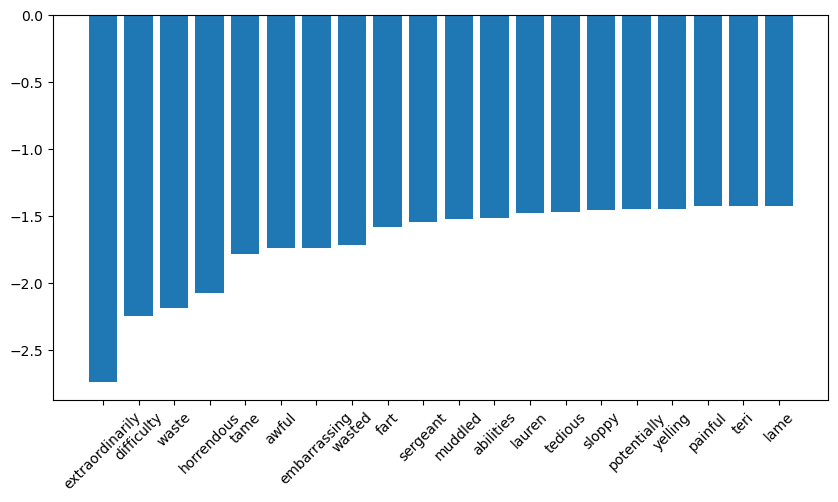

In [21]:
weights = vectorizer.inverse_transform(lr.coef_)[0]
sorted_weights = sorted(weights.items(), key=lambda t: t[1])
util.plot_bar_graph([w for _,w in sorted_weights[:20]],
                    [f for f,_ in sorted_weights[:20]],rotation=45)

More obvious **discriminative** features for the negative class 

* Conditional log-likelihood down-weighs a feature $f_i$ for $y=-$ 
    * if $f_i$ is active in $\x$
    * but gold label is $y=+$



Positive weights? 

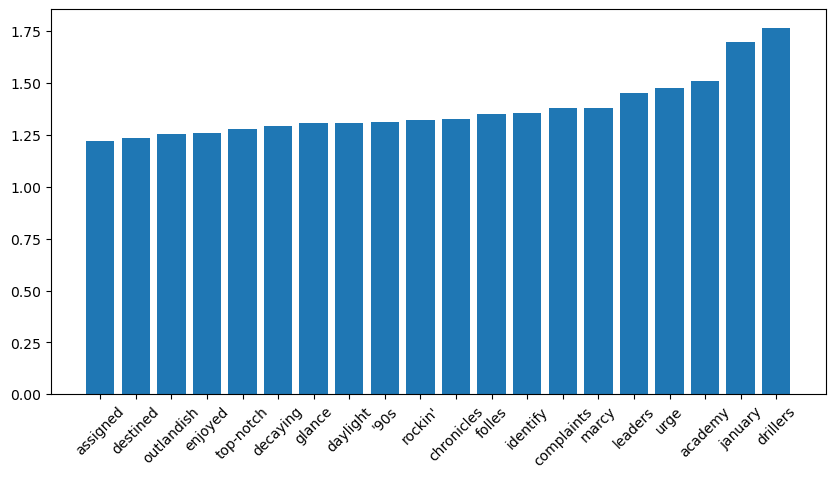

In [22]:
util.plot_bar_graph([w for _,w in sorted_weights[-20:]],
                    [f for f,_ in sorted_weights[-20:]],rotation=45)

## Evaluation

How can we quantify how well our models do?

Use **accuracy**, the ratio of the 

* number of correct predictions and the 
* number of all predictions  

$\hat{\y}$ is predicted sequence of labels, $\y$ the true labels:

$$
\mathrm{Acc}(y_1,\ldots,y_n, \hat{y}_1,\ldots,\hat{y}_n) = \frac{\sum_i \indi [ y_i = \hat{y}_i]}{n}
$$

In [23]:
def accuracy(gold, guess):
    correct = 0
    for y_gold,y_guess in zip(gold,guess):
        if y_guess == y_gold:
            correct += 1
    return correct / len(gold)

train_Y_lex = [y for _,y in train]
dev_Y_lex = [y for _,y in dev]

In [24]:
lr = LogisticRegression(C=1000, penalty="l2",random_state=1, tol=0.00001, solver='liblinear')
lr.fit(train_X, train_Y)
lr_guess = label_encoder.inverse_transform(lr.predict(dev_X))
print(f"dev accuracy = {accuracy(dev_Y_lex, lr_guess)}")

dev accuracy = 0.895


## Summary

* Text classification can be framed as **discriminative** learning problem
    * Learn how to *discriminate best output based on input*
    * Increase relative/conditional probability of classes
* Ingredients
    * Model (commonly used: logistic regression)
    * Feature function
    * Regularisation
* Evaluation
    * Quantitative evaluation: measure accuracy
    * Qualitative evaluation: inspect feature weights

## Background material

* [Baselines and Bigrams: Simple, Good Sentiment and Topic Classification](https://aclanthology.org/P12-2018/), Sida Wang and Christopher D. Manning, ACL 2012
* [Thumbs up? Sentiment Classification using Machine Learning Techniques](https://www.cs.cornell.edu/home/llee/papers/sentiment.pdf), Bo Pang, Lillian Lee and Shivakumar Vaithyanathan, EMNLP 2002
* Jurafsky & Martin, *Speech and Language Processing* (2026):
  * [Appendix B: Naive Bayes and Sentiment Classification](https://web.stanford.edu/~jurafsky/slp3/B.pdf)
  * [Chapter 4: Logistic Regression](https://web.stanford.edu/~jurafsky/slp3/4.pdf)